In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, UpSampling2D, InputLayer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os

# Google Drive 경로 설정
grayscale_path = "/content/drive/My Drive/dataset/gray/gray_scale.npy"
ab_dir = "/content/drive/My Drive/dataset/ab/ab"

# 흑백 이미지 로드
grayscale_images = np.load(grayscale_path)

# ab 파일 로드 및 병합
ab_files = [os.path.join(ab_dir, f"ab{i}.npy") for i in range(1, 4)]
ab_images = np.concatenate([np.load(file) for file in ab_files], axis=0)

grayscale_images = grayscale_images[:10000]  # 흑백 이미지
ab_images = ab_images[:10000]                # 컬러 정보

# 데이터 크기 확인
print("Grayscale images shape:", grayscale_images.shape)  # 예: (10000, H, W, 1)
print("AB images shape:", ab_images.shape)

Grayscale images shape: (10000, 224, 224)
AB images shape: (10000, 224, 224, 2)


In [15]:
from sklearn.model_selection import train_test_split

# 데이터 정규화 (0~1 범위로)
grayscale_images = grayscale_images / 255.0
ab_images = ab_images / 255.0

# 입력 데이터 차원 추가 (채널 추가)
grayscale_images = grayscale_images[..., np.newaxis]  # (N, 224, 224) -> (N, 224, 224, 1)

# 학습 및 검증 데이터 분리
x_train, x_val, y_train, y_val = train_test_split(grayscale_images, ab_images, test_size=0.2, random_state=42)

print("Training data shape:", x_train.shape, y_train.shape)  # (N, 224, 224, 1), (N, 224, 224, 2)
print("Validation data shape:", x_val.shape, y_val.shape)

# CNN 모델 설계
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, UpSampling2D, InputLayer
from tensorflow.keras.optimizers import Adam

def create_colorization_model(input_shape=(224, 224, 1)):  # 입력 크기 수정
    model = Sequential([
        InputLayer(input_shape=input_shape),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        Conv2D(16, (3, 3), activation='relu', padding='same'),
        Conv2D(2, (3, 3), activation='tanh', padding='same')  # ab 채널 출력
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    return model

# 모델 생성
model = create_colorization_model(input_shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3]))

# 모델 학습
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32
)


Training data shape: (8000, 224, 224, 1) (8000, 224, 224, 2)
Validation data shape: (2000, 224, 224, 1) (2000, 224, 224, 2)
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.0383 - val_loss: 0.0041
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0041 - val_loss: 0.0043
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0040 - val_loss: 0.0042
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0040 - val_loss: 0.0042
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0040 - val_loss: 0.0042
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0040 - val_loss: 0.0041
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0040 - val_loss: 0.0042
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0040 - val_loss: 0.0040


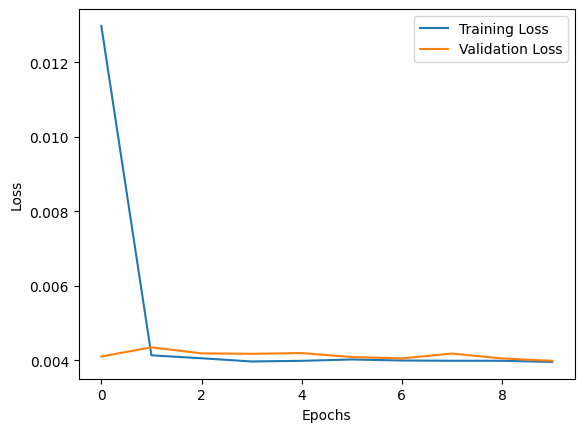

In [16]:
import matplotlib.pyplot as plt

# 학습 결과 시각화
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


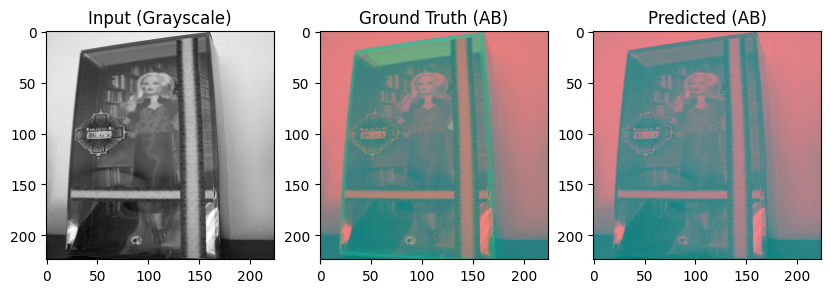

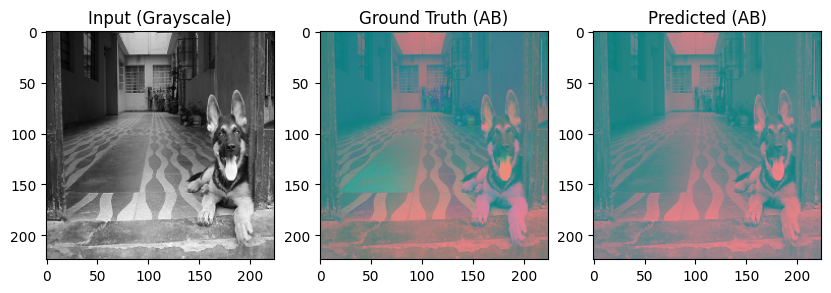

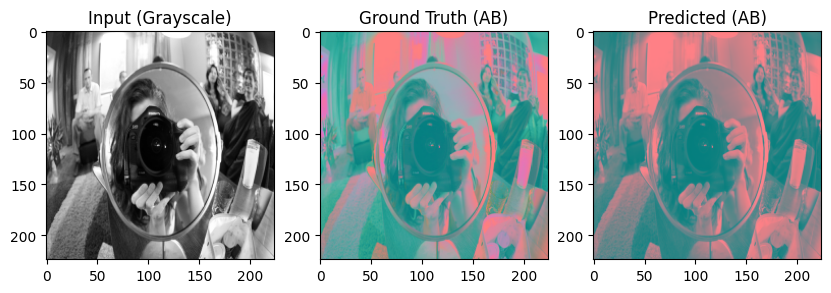

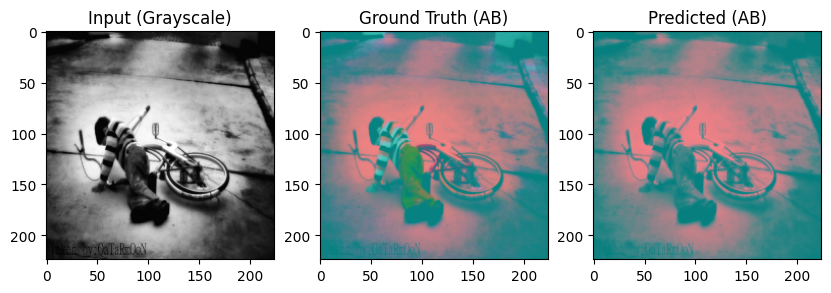

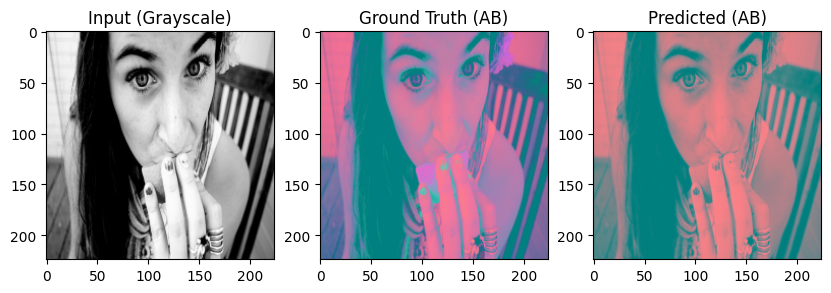

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 결과 확인 함수
def display_results(model, x, y):
    preds = model.predict(x)
    for i in range(5):  # 5개의 샘플 출력
        plt.figure(figsize=(10, 4))

        # 흑백 입력
        plt.subplot(1, 3, 1)
        gray_image = x[i].squeeze()  # (H, W, 1) -> (H, W)
        plt.imshow(gray_image, cmap='gray')
        plt.title("Input (Grayscale)")

        # Ground Truth
        plt.subplot(1, 3, 2)
        ground_truth = cv2.merge([
            gray_image.astype(np.float32),  # 데이터 타입 일치
            y[i][..., 0].astype(np.float32),
            y[i][..., 1].astype(np.float32)
        ])
        plt.imshow(ground_truth)
        plt.title("Ground Truth (AB)")

        # 예측 결과
        plt.subplot(1, 3, 3)
        prediction = cv2.merge([
            gray_image.astype(np.float32),  # 데이터 타입 일치
            preds[i][..., 0].astype(np.float32),
            preds[i][..., 1].astype(np.float32)
        ])
        plt.imshow(prediction)
        plt.title("Predicted (AB)")

        plt.show()

# 결과 확인
display_results(model, x_val[:5], y_val[:5])